# EfficientNet and added dense layers

| **Task**                                        | **Sub-task**                                                 | **Comments**                                                                                                                                                           |
|-------------------------------------------------|--------------------------------------------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **Data Preprocessing**                          | Scaling and Resizing                                         | **Done:** Images are resized to224x224 and normalized.                                                                                                                |
| **Image Augmentation**                          |                                                              | **Done:** Random flips and rotations were applied (in the 2nd tuning round) to increase image diversity.                                                              |
| **Train and Test Data Handling**                |                                                              | **Done:** Data is split using stratified sampling into train/validation/test sets, and tf.data generators are used to load data on the fly.                           |
| **Gaussian Blur, Histogram Equalization and Intensity Thresholds** |                                              | **Done:** These techniques were demonstrated in the EDA cell to explore image characteristics.                                                                         |
| **Model Trained**                               |                                               | **Done:** A transfer‑learned model based on EfficientNetB0 (with added dense layers for additional metadata features) was trained. Training time varies by hardware.  |
| **AUC and Confusion Matrix Computed**           |                                                              | **Done:** AUC values were computed, and the confusion matrix was displayed using ConfusionMatrixDisplay (without using seaborn).                                           |
| **Overfitting/Underfitting Checked and Handled**|                                                              | **Done:** Overfitting was mitigated by fine‑tuning (unfreezing top layers and lowering the learning rate); underfitting was addressed via image augmentation.          |
| **Empirical Tuning / Interpretability Implemented** |                                                          | **Done:** Two rounds of empirical tuning were performed and Grad‑CAM was used for interpretability. The model, however, still showed bias toward the majority class.   |
| **1st Round of Tuning**                         | Issue Faced/Fixed                                            | **Issue:** The model initially overfitted to the majority class. <br>**Fixed:** Unfreezing only the top layers and lowering the learning rate improved performance.  |
| **2nd Round of Tuning**                         | Issue Faced/Fixed                                            | **Issue:** Minority classes remained underrepresented. <br>**Fixed:** On‑the‑fly image augmentation was applied to improve data diversity; further refinement may be needed.  |


### Convert JSON to CSV

In [2]:
import json
import csv

# Set paths for JSON input and CSV output
json_file = "yelp_photos/photos.json"       
csv_file = "photos.csv"          

print("Converting JSON to CSV ...")
with open(json_file, 'r', encoding='utf-8') as jf, open(csv_file, 'w', newline='', encoding='utf-8') as cf:
    writer = csv.writer(cf)
    # Write header row: photo_id, business_id, caption, label
    writer.writerow(["photo_id", "business_id", "caption", "label"])
    for line in jf:
        line = line.strip()
        if not line:
            continue
        try:
            data = json.loads(line)
        except json.JSONDecodeError as e:
            print(f"Skipping invalid JSON line: {e}")
            continue
        writer.writerow([
            data.get("photo_id", ""),
            data.get("business_id", ""),
            data.get("caption", ""),
            data.get("label", "")
        ])
print("JSON to CSV conversion completed!")

Converting JSON to CSV ...
JSON to CSV conversion completed!


## Load CSV and Sample 10,000 Rows

In [4]:
import pandas as pd

# Load the CSV file
df = pd.read_csv(csv_file)
print("Total records in CSV:", len(df))

# Define the list of classes
classes = ['drink', 'food', 'inside', 'menu', 'outside']

# For each class, sample up to 5100 rows without replacement
samples = []
for c in classes:
    df_class = df[df['label'] == c]
    n = 5000 if len(df_class) >= 5000 else len(df_class)
    sample_c = df_class.sample(n=n, random_state=42, replace=False)
    samples.append(sample_c)

# Concatenate all the sampled DataFrames
sample_df = pd.concat(samples)
print("Sampled records:", len(sample_df))


Total records in CSV: 200100
Sampled records: 21678


Verify Images

In [6]:
from PIL import Image
import os

images_dir = "yelp_photos/photos"   

def is_image_valid(image_path):
    try:
        with Image.open(image_path) as img:
            img.verify()
        return True
    except Exception as e:
        print(f"Image {image_path} is invalid: {e}")
        return False

valid_rows = []
for idx, row in sample_df.iterrows():
    photo_id = row['photo_id']
    image_path = os.path.join(images_dir, f"{photo_id}.jpg")
    if not os.path.exists(image_path):
        continue
    if is_image_valid(image_path):
        valid_rows.append(row)

valid_sample_df = pd.DataFrame(valid_rows)
print("Number of valid images:", len(valid_sample_df))

Image yelp_photos/photos\l_rMdwgrvjm2PyHyXBcBTw.jpg is invalid: cannot identify image file 'yelp_photos/photos\\l_rMdwgrvjm2PyHyXBcBTw.jpg'
Image yelp_photos/photos\1wd_eyhMrTqUmicDmn4_Kw.jpg is invalid: cannot identify image file 'yelp_photos/photos\\1wd_eyhMrTqUmicDmn4_Kw.jpg'
Image yelp_photos/photos\kjMBhxBXOUE7SSUQb-YQbw.jpg is invalid: cannot identify image file 'yelp_photos/photos\\kjMBhxBXOUE7SSUQb-YQbw.jpg'
Image yelp_photos/photos\RhC7TNmFvbR9GWrlrl5dsA.jpg is invalid: cannot identify image file 'yelp_photos/photos\\RhC7TNmFvbR9GWrlrl5dsA.jpg'
Image yelp_photos/photos\tSHz7RzlgceAItRejZ396A.jpg is invalid: cannot identify image file 'yelp_photos/photos\\tSHz7RzlgceAItRejZ396A.jpg'
Image yelp_photos/photos\QhATx1B1n8uf8C6siMNTfA.jpg is invalid: cannot identify image file 'yelp_photos/photos\\QhATx1B1n8uf8C6siMNTfA.jpg'
Image yelp_photos/photos\OK6HsALzFcBAUlrroKHZGg.jpg is invalid: cannot identify image file 'yelp_photos/photos\\OK6HsALzFcBAUlrroKHZGg.jpg'
Image yelp_photos/ph

# Exploratory Data Analysis (EDA)

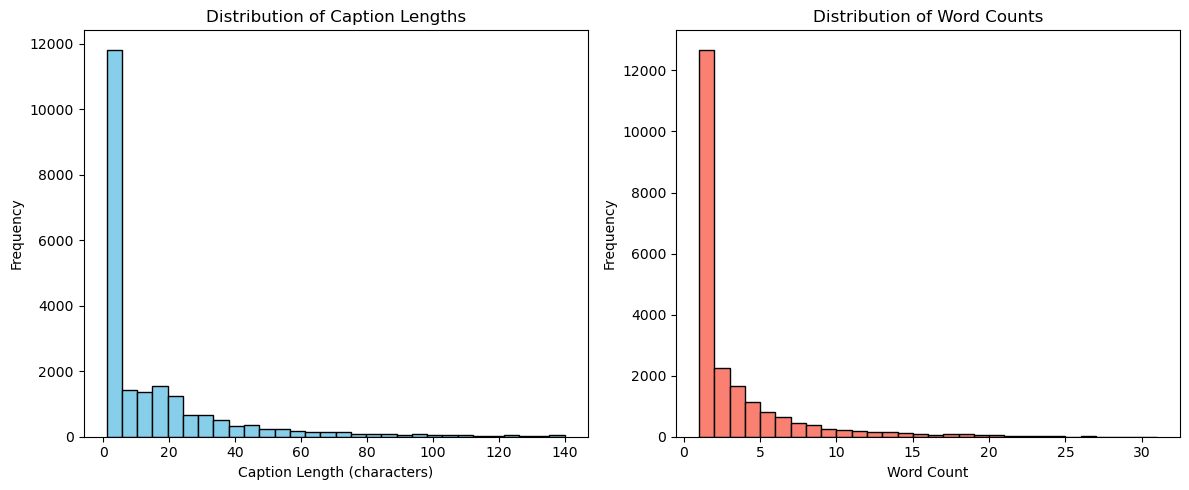

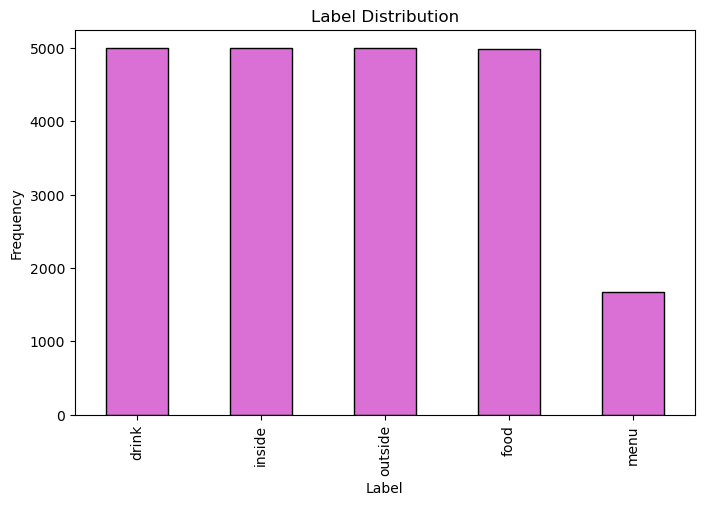

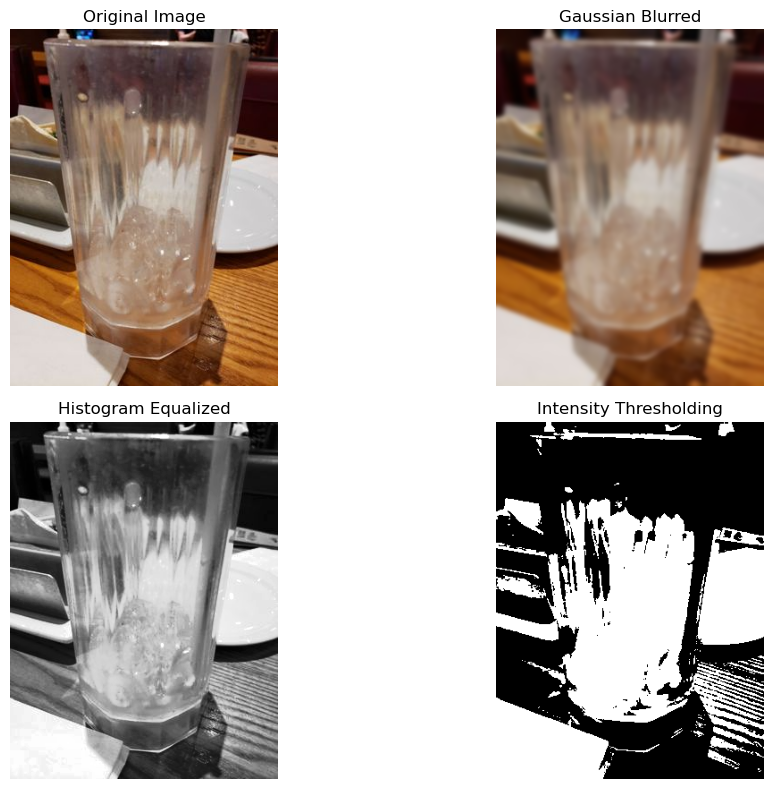

EDA complete!


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# --- Metadata EDA ---
caption_lengths = valid_sample_df["caption"].apply(lambda x: len(str(x)))
word_counts = valid_sample_df["caption"].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(caption_lengths, bins=30, color='skyblue', edgecolor='black')
plt.title("Distribution of Caption Lengths")
plt.xlabel("Caption Length (characters)")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(word_counts, bins=30, color='salmon', edgecolor='black')
plt.title("Distribution of Word Counts")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# --- Label Distribution ---
label_counts = valid_sample_df["label"].value_counts()
plt.figure(figsize=(8, 5))
label_counts.plot(kind='bar', color='orchid', edgecolor='black')
plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Frequency")
plt.show()

# --- Image Processing Techniques ---
sample_row = valid_sample_df.iloc[110]
sample_photo_id = sample_row["photo_id"]
sample_image_path = os.path.join(images_dir, f"{sample_photo_id}.jpg")
sample_image = cv2.imread(sample_image_path)
sample_image_rgb = cv2.cvtColor(sample_image, cv2.COLOR_BGR2RGB)

# Apply Gaussian Blur
blurred = cv2.GaussianBlur(sample_image_rgb, (15, 15), 0)

# Histogram Equalization (on grayscale)
gray = cv2.cvtColor(sample_image_rgb, cv2.COLOR_RGB2GRAY)
equalized = cv2.equalizeHist(gray)

# Intensity Thresholding
_, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.imshow(sample_image_rgb)
plt.title("Original Image")
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(blurred)
plt.title("Gaussian Blurred")
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(equalized, cmap='gray')
plt.title("Histogram Equalized")
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(thresh, cmap='gray')
plt.title("Intensity Thresholding")
plt.axis('off')

plt.tight_layout()
plt.show()

print("EDA complete!")


# Step 2: Create a Data Generator with tf.data

We create a data pipeline that loads images and computes metadata on the fly.  
Metadata features here are: caption length and word count.


# Prepare Data for Training

In [11]:
import tensorflow as tf
import numpy as np

# Define image dimensions
IMG_HEIGHT, IMG_WIDTH = 224, 224

# Create label vocabulary (sorted)
label_vocab = sorted(valid_sample_df["label"].unique().tolist())
print("Label vocabulary:", label_vocab)

# Create a lookup table to map label strings to integer indices
table = tf.lookup.StaticHashTable(
    initializer=tf.lookup.KeyValueTensorInitializer(
        keys=tf.constant(label_vocab),
        values=tf.constant(list(range(len(label_vocab))), dtype=tf.int64)
    ),
    default_value=-1
)

# Function to load and preprocess image
def load_image(image_path):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMG_HEIGHT, IMG_WIDTH])
    image = image / 255.0
    return image

# Function to compute metadata (caption length and word count)
def get_meta_features(caption):
    length = tf.cast(tf.strings.length(caption), tf.float32)
    words = tf.strings.split(caption)
    word_count = tf.cast(tf.size(words), tf.float32)
    return tf.stack([length, word_count])

# Process a single row: given photo_id, caption, and label, return (image, metadata) and one-hot label
def process_row(photo_id, caption, label):
    image_path = tf.strings.join([images_dir, "/", photo_id, ".jpg"])
    image = load_image(image_path)
    meta = get_meta_features(caption)
    label_int = table.lookup(label)
    label_onehot = tf.one_hot(label_int, depth=len(label_vocab))
    return (image, meta), label_onehot

# Create a tf.data.Dataset from a DataFrame
def create_dataset_from_df(df, batch_size=32, shuffle=True):
    photo_ids = df["photo_id"].astype(str).values
    captions  = df["caption"].astype(str).values
    labels    = df["label"].astype(str).values
    ds = tf.data.Dataset.from_tensor_slices((photo_ids, captions, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), seed=42)
    ds = ds.map(process_row, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

Label vocabulary: ['drink', 'food', 'inside', 'menu', 'outside']


# Split Data into Train/Validation/Test Sets

In [13]:
# Split valid_sample_df into train, validation, and test sets (70/15/15)
from sklearn.model_selection import train_test_split
df_train, df_temp = train_test_split(valid_sample_df, test_size=0.3, random_state=42, stratify=valid_sample_df["label"])
df_val, df_test = train_test_split(df_temp, test_size=0.5, random_state=42, stratify=df_temp["label"])

print("Train samples:", len(df_train))
print("Validation samples:", len(df_val))
print("Test samples:", len(df_test))

batch_size = 32
train_dataset = create_dataset_from_df(df_train, batch_size=batch_size, shuffle=True)
val_dataset   = create_dataset_from_df(df_val, batch_size=batch_size, shuffle=False)
test_dataset  = create_dataset_from_df(df_test, batch_size=batch_size, shuffle=False)

Train samples: 15165
Validation samples: 3250
Test samples: 3250


# Step 6: Build the Multi-Input Model

We build a model with two branches:
- An image branch using EfficientNetB0.
- A metadata branch processing the extra features.
These branches are then concatenated and fed into further dense layers for classification.


In [15]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, Dropout, Concatenate
from tensorflow.keras.models import Model

# Image branch
img_input = Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3), name='image_input')
base_model = EfficientNetB0(include_top=False, weights='imagenet', input_tensor=img_input)
base_model.trainable = False  # Freeze initially

x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)

# Metadata branch (2 features)
meta_input = Input(shape=(2,), name='meta_input')
y = Dense(64, activation='relu')(meta_input)
y = Dropout(0.5)(y)
y = Dense(32, activation='relu')(y)

# Combine branches
combined = Concatenate()([x, y])
z = Dense(64, activation='relu')(combined)
z = Dropout(0.5)(z)
num_classes = len(label_vocab)
output = Dense(num_classes, activation='softmax', name='output')(z)

model = Model(inputs=[img_input, meta_input], outputs=output)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ image_input[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,398,600 (16.78 MB)

 Trainable params: 349,029 (1.33 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

# Step 7: Compile and Train the Model (Initial Training)

We compile the model with the Adam optimizer and categorical crossentropy loss.  
Early stopping and checkpoint callbacks are used during training.


In [17]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Compile the model with standard categorical crossentropy loss
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint     = ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True)

print("Training the model (initial training) with standard categorical crossentropy...")
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    callbacks=[early_stopping, checkpoint]
)
print("Initial training complete!")

Training the model (initial training) with standard categorical crossentropy...
Epoch 1/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step - accuracy: 0.2267 - auc: 0.5603 - loss: 1.7479

474/474 ━━━━━━━━━━━━━━━━━━━━ 174s 348ms/step - accuracy: 0.2267 - auc: 0.5603 - loss: 1.7476 - val_accuracy: 0.2258 - val_auc: 0.5749 - val_loss: 1.5676
Epoch 2/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - accuracy: 0.2286 - auc: 0.5789 - loss: 1.5642

474/474 ━━━━━━━━━━━━━━━━━━━━ 170s 358ms/step - accuracy: 0.2286 - auc: 0.5789 - loss: 1.5642 - val_accuracy: 0.2317 - val_auc: 0.5865 - val_loss: 1.5581
Epoch 3/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - accuracy: 0.2218 - auc: 0.5758 - loss: 1.5603

474/474 ━━━━━━━━━━━━━━━━━━━━ 165s 349ms/step - accuracy: 0.2218 - auc: 0.5758 - loss: 1.5603 - val_accuracy: 0.2308 - val_auc: 0.5802 - val_loss: 1.5511
Epoch 4/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - accuracy: 0.2259 - auc: 0.5747 - loss: 1.5574

474/474 ━━━━━━━━━━━━━━━━━━━━ 170s 359ms/step - accuracy: 0.2259 - auc: 0.5747 - loss: 1.5574 - val_accuracy: 0.2262 - val_auc: 0.5798 - val_loss: 1.5508
Epoch 5/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 169s 358ms/step - accuracy: 0.2416 - auc: 0.5832 - loss: 1.5541 - val_accuracy: 0.2422 - val_auc: 0.5864 - val_loss: 1.5512
Epoch 6/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 170s 359ms/step - accuracy: 0.2299 - auc: 0.5797 - loss: 1.5520 - val_accuracy: 0.2311 - val_auc: 0.5774 - val_loss: 1.5517
Epoch 7/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - accuracy: 0.2366 - auc: 0.5792 - loss: 1.5507

474/474 ━━━━━━━━━━━━━━━━━━━━ 172s 362ms/step - accuracy: 0.2366 - auc: 0.5792 - loss: 1.5507 - val_accuracy: 0.2385 - val_auc: 0.5846 - val_loss: 1.5508
Epoch 8/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - accuracy: 0.2221 - auc: 0.5728 - loss: 1.5523

474/474 ━━━━━━━━━━━━━━━━━━━━ 172s 363ms/step - accuracy: 0.2221 - auc: 0.5728 - loss: 1.5523 - val_accuracy: 0.2415 - val_auc: 0.5893 - val_loss: 1.5504
Epoch 9/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 171s 362ms/step - accuracy: 0.2436 - auc: 0.5883 - loss: 1.5495 - val_accuracy: 0.2308 - val_auc: 0.5768 - val_loss: 1.5516
Epoch 10/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 171s 362ms/step - accuracy: 0.2336 - auc: 0.5827 - loss: 1.5485 - val_accuracy: 0.2375 - val_auc: 0.5824 - val_loss: 1.5511
Epoch 11/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 171s 361ms/step - accuracy: 0.2338 - auc: 0.5828 - loss: 1.5502 - val_accuracy: 0.2317 - val_auc: 0.5783 - val_loss: 1.5516
Epoch 12/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 173s 365ms/step - accuracy: 0.2276 - auc: 0.5768 - loss: 1.5519 - val_accuracy: 0.2354 - val_auc: 0.5857 - val_loss: 1.5509
Epoch 13/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 174s 368ms/step - accuracy: 0.2302 - auc: 0.5796 - loss: 1.5505 - val_accuracy: 0.2354 - val_auc: 0.5797 - val_loss: 1.5514
Initial training comple

# Step 8: Initial Evaluation

We evaluate the initially trained model on the test set and generate metrics such as loss, accuracy, AUC, confusion matrix, and classification report.


Evaluating the model on the test set ...
Test Loss: 1.5494 | Test Accuracy: 0.2400 | Test AUC: 0.5895
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step
1/1 

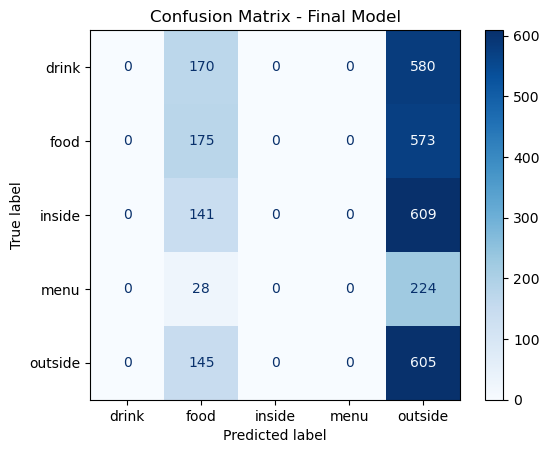

Classification Report (Final Model):
              precision    recall  f1-score   support

       drink       0.00      0.00      0.00       750
        food       0.27      0.23      0.25       748
      inside       0.00      0.00      0.00       750
        menu       0.00      0.00      0.00       252
     outside       0.23      0.81      0.36       750

    accuracy                           0.24      3250
   macro avg       0.10      0.21      0.12      3250
weighted avg       0.12      0.24      0.14      3250



C:\Users\gaura\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\gaura\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\gaura\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


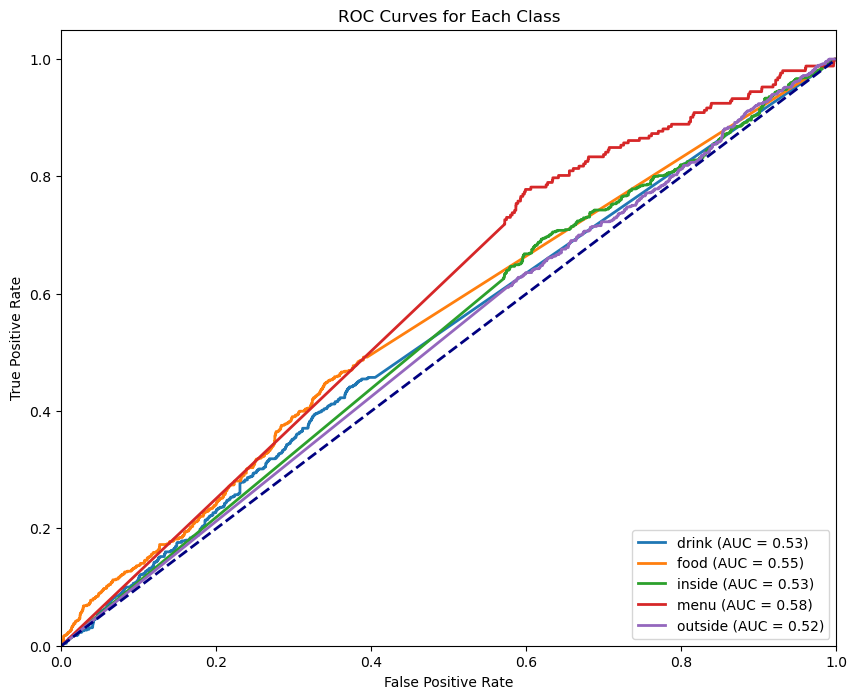

Overall Test AUC Score (OVR): 0.5424


In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, auc, roc_auc_score
import tensorflow as tf

# Evaluate on test_dataset
print("Evaluating the model on the test set ...")
results = model.evaluate(test_dataset, verbose=0)
print("Test Loss: {:.4f} | Test Accuracy: {:.4f} | Test AUC: {:.4f}".format(*results))

# Gather true labels and predictions from the test dataset
y_true_all = []
y_pred_all = []
all_predictions = []  # for ROC curve
for (x_batch, y_batch) in test_dataset:
    preds = model.predict(x_batch)
    all_predictions.extend(preds)
    y_pred_all.extend(preds.argmax(axis=1))
    y_true_all.extend(y_batch.numpy().argmax(axis=1))
all_predictions = np.array(all_predictions)

# Confusion Matrix using ConfusionMatrixDisplay
cm = confusion_matrix(y_true_all, y_pred_all)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_vocab)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Final Model')
plt.show()

print("Classification Report (Final Model):")
print(classification_report(y_true_all, y_pred_all, target_names=label_vocab))

# Compute ROC curves for each class
y_true_onehot = tf.keras.utils.to_categorical(y_true_all, num_classes=len(label_vocab))
plt.figure(figsize=(10, 8))
for i, class_name in enumerate(label_vocab):
    fpr, tpr, _ = roc_curve(y_true_onehot[:, i], all_predictions[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{class_name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Each Class')
plt.legend(loc="lower right")
plt.show()

# Also compute and print the overall multi-class AUC (one-vs-rest)
overall_auc = roc_auc_score(y_true_onehot, all_predictions, multi_class='ovr')
print("Overall Test AUC Score (OVR): {:.4f}".format(overall_auc))


# Step 9: 1st Round of Fine Tuning

In the first fine-tuning round, we unfreeze the top layers of the base model (keeping lower layers frozen) and retrain with a lower learning rate.  
This round aims to address any overfitting observed in the initial training.


In [21]:
# Unfreeze the top layers of the base model for fine tuning
print("Starting 1st round of fine tuning...")
base_model.trainable = True
# Freeze all layers except the top 20 layers of the base model
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Recompile with a lower learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

history_ft1 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    callbacks=[early_stopping, checkpoint]
)
print("1st round of fine tuning complete!")


Starting 1st round of fine tuning...
Epoch 1/10
474/474 ━━━━━━━━━━━━━━━━━━━━ 213s 424ms/step - accuracy: 0.2417 - auc: 0.5910 - loss: 1.5541 - val_accuracy: 0.2397 - val_auc: 0.5903 - val_loss: 1.5505
Epoch 2/10
474/474 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step - accuracy: 0.2417 - auc: 0.5856 - loss: 1.5532

474/474 ━━━━━━━━━━━━━━━━━━━━ 191s 404ms/step - accuracy: 0.2417 - auc: 0.5856 - loss: 1.5532 - val_accuracy: 0.2462 - val_auc: 0.5991 - val_loss: 1.5497
Epoch 3/10
474/474 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step - accuracy: 0.2382 - auc: 0.5906 - loss: 1.5492

474/474 ━━━━━━━━━━━━━━━━━━━━ 193s 407ms/step - accuracy: 0.2382 - auc: 0.5906 - loss: 1.5492 - val_accuracy: 0.2865 - val_auc: 0.6449 - val_loss: 1.5465
Epoch 4/10
474/474 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - accuracy: 0.2434 - auc: 0.5976 - loss: 1.5466

474/474 ━━━━━━━━━━━━━━━━━━━━ 192s 405ms/step - accuracy: 0.2434 - auc: 0.5976 - loss: 1.5466 - val_accuracy: 0.2889 - val_auc: 0.6478 - val_loss: 1.5162
Epoch 5/10
474/474 ━━━━━━━━━━━━━━━━━━━━ 192s 405ms/step - accuracy: 0.2571 - auc: 0.6079 - loss: 1.5439 - val_accuracy: 0.2535 - val_auc: 0.6153 - val_loss: 1.5476
Epoch 6/10
474/474 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.2723 - auc: 0.6235 - loss: 1.5343

474/474 ━━━━━━━━━━━━━━━━━━━━ 192s 405ms/step - accuracy: 0.2723 - auc: 0.6235 - loss: 1.5342 - val_accuracy: 0.3428 - val_auc: 0.7011 - val_loss: 1.4896
Epoch 7/10
474/474 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step - accuracy: 0.2843 - auc: 0.6432 - loss: 1.5250

474/474 ━━━━━━━━━━━━━━━━━━━━ 187s 394ms/step - accuracy: 0.2843 - auc: 0.6432 - loss: 1.5250 - val_accuracy: 0.3437 - val_auc: 0.7030 - val_loss: 1.4735
Epoch 8/10
474/474 ━━━━━━━━━━━━━━━━━━━━ 184s 387ms/step - accuracy: 0.2934 - auc: 0.6492 - loss: 1.5212 - val_accuracy: 0.2308 - val_auc: 0.5767 - val_loss: 1.5529
Epoch 9/10
474/474 ━━━━━━━━━━━━━━━━━━━━ 183s 387ms/step - accuracy: 0.3011 - auc: 0.6632 - loss: 1.5076 - val_accuracy: 0.2317 - val_auc: 0.5778 - val_loss: 1.5533
Epoch 10/10
474/474 ━━━━━━━━━━━━━━━━━━━━ 184s 388ms/step - accuracy: 0.3120 - auc: 0.6713 - loss: 1.4988 - val_accuracy: 0.2631 - val_auc: 0.6201 - val_loss: 1.9638
1st round of fine tuning complete!


# Step 10: Evaluation after 1st Fine Tuning

We evaluate the model again after the first round of fine tuning.


Evaluating model after 1st fine tuning ...
Test Loss: 1.4812 | Test Accuracy: 0.3366 | Test AUC: 0.6931
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step
1/

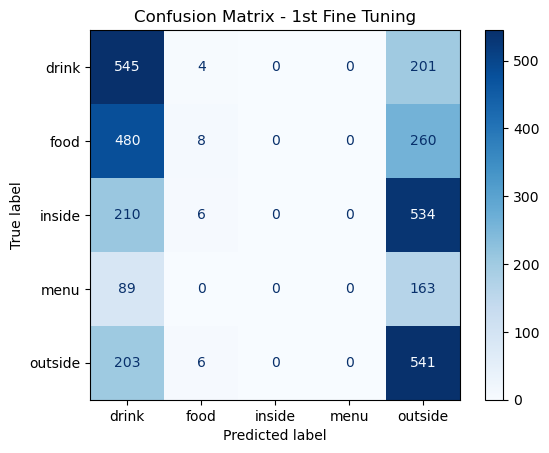

Classification Report (After 1st Fine Tuning):
              precision    recall  f1-score   support

       drink       0.36      0.73      0.48       750
        food       0.33      0.01      0.02       748
      inside       0.00      0.00      0.00       750
        menu       0.00      0.00      0.00       252
     outside       0.32      0.72      0.44       750

    accuracy                           0.34      3250
   macro avg       0.20      0.29      0.19      3250
weighted avg       0.23      0.34      0.22      3250

Test AUC Score (After 1st Fine Tuning): 0.6526


C:\Users\gaura\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\gaura\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\gaura\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [23]:
print("Evaluating model after 1st fine tuning ...")
results_ft1 = model.evaluate(test_dataset, verbose=0)
print("Test Loss: {:.4f} | Test Accuracy: {:.4f} | Test AUC: {:.4f}".format(*results_ft1))

y_true_all_ft1 = []
y_pred_all_ft1 = []
all_predictions_ft1 = []
for (x_batch, y_batch) in test_dataset:
    preds = model.predict(x_batch)
    all_predictions_ft1.extend(preds)
    y_pred_all_ft1.extend(preds.argmax(axis=1))
    y_true_all_ft1.extend(y_batch.numpy().argmax(axis=1))
all_predictions_ft1 = np.array(all_predictions_ft1)

cm_ft1 = confusion_matrix(y_true_all_ft1, y_pred_all_ft1)
disp_ft1 = ConfusionMatrixDisplay(confusion_matrix=cm_ft1, display_labels=label_vocab)
disp_ft1.plot(cmap='Blues')
plt.title('Confusion Matrix - 1st Fine Tuning')
plt.show()

print("Classification Report (After 1st Fine Tuning):")
print(classification_report(y_true_all_ft1, y_pred_all_ft1, target_names=label_vocab))

y_true_onehot_ft1 = tf.keras.utils.to_categorical(y_true_all_ft1, num_classes=len(label_vocab))
overall_auc_ft1 = roc_auc_score(y_true_onehot_ft1, all_predictions_ft1, multi_class='ovr')
print("Test AUC Score (After 1st Fine Tuning): {:.4f}".format(overall_auc_ft1))


# Step 11: 2nd Round of Fine Tuning with Image Augmentation

In the second fine-tuning round, we incorporate image augmentation to further improve generalization.  
A custom generator applies random transformations (rotations, zooms, flips) during training.


In [25]:
# Define an augmentation function that applies random flips and rotations
def augment_fn(x, y):
    image, meta = x
    image = tf.image.random_flip_left_right(image)
    image = tf.image.rot90(image, k=tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32))
    return (image, meta), y

# Create an augmented training dataset by mapping the augmentation function onto the training dataset
aug_train_dataset = train_dataset.map(augment_fn, num_parallel_calls=tf.data.AUTOTUNE)

print("Starting 2nd round of fine tuning with augmentation...")
# Optionally, you can continue with the current unfreeze state.
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

history_ft2 = model.fit(
    aug_train_dataset,
    validation_data=val_dataset,
    epochs=10,
    callbacks=[early_stopping, checkpoint]
)
print("2nd round of fine tuning complete!")


Starting 2nd round of fine tuning with augmentation...
Epoch 1/10
474/474 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - accuracy: 0.2933 - auc: 0.6532 - loss: 1.5140

474/474 ━━━━━━━━━━━━━━━━━━━━ 206s 409ms/step - accuracy: 0.2933 - auc: 0.6532 - loss: 1.5140 - val_accuracy: 0.3449 - val_auc: 0.6876 - val_loss: 1.4713
Epoch 2/10
474/474 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - accuracy: 0.3050 - auc: 0.6663 - loss: 1.5051

474/474 ━━━━━━━━━━━━━━━━━━━━ 189s 399ms/step - accuracy: 0.3050 - auc: 0.6663 - loss: 1.5051 - val_accuracy: 0.3375 - val_auc: 0.7104 - val_loss: 1.4505
Epoch 3/10
474/474 ━━━━━━━━━━━━━━━━━━━━ 216s 455ms/step - accuracy: 0.3017 - auc: 0.6738 - loss: 1.4960 - val_accuracy: 0.2655 - val_auc: 0.6262 - val_loss: 1.8663
Epoch 4/10
474/474 ━━━━━━━━━━━━━━━━━━━━ 235s 496ms/step - accuracy: 0.3114 - auc: 0.6738 - loss: 1.4950 - val_accuracy: 0.2428 - val_auc: 0.5885 - val_loss: 2.4754
Epoch 5/10
474/474 ━━━━━━━━━━━━━━━━━━━━ 216s 455ms/step - accuracy: 0.3019 - auc: 0.6725 - loss: 1.4957 - val_accuracy: 0.2394 - val_auc: 0.5909 - val_loss: 2.4286
Epoch 6/10
474/474 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 0.3071 - auc: 0.6694 - loss: 1.4993

474/474 ━━━━━━━━━━━━━━━━━━━━ 229s 482ms/step - accuracy: 0.3071 - auc: 0.6694 - loss: 1.4993 - val_accuracy: 0.3554 - val_auc: 0.7219 - val_loss: 1.4352
Epoch 7/10
474/474 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - accuracy: 0.3075 - auc: 0.6729 - loss: 1.4964

474/474 ━━━━━━━━━━━━━━━━━━━━ 228s 481ms/step - accuracy: 0.3075 - auc: 0.6729 - loss: 1.4964 - val_accuracy: 0.3483 - val_auc: 0.7163 - val_loss: 1.4297
Epoch 8/10
474/474 ━━━━━━━━━━━━━━━━━━━━ 211s 444ms/step - accuracy: 0.3141 - auc: 0.6803 - loss: 1.4876 - val_accuracy: 0.2625 - val_auc: 0.6049 - val_loss: 2.1439
Epoch 9/10
474/474 ━━━━━━━━━━━━━━━━━━━━ 205s 431ms/step - accuracy: 0.3152 - auc: 0.6783 - loss: 1.4915 - val_accuracy: 0.3108 - val_auc: 0.6684 - val_loss: 1.5964
Epoch 10/10
474/474 ━━━━━━━━━━━━━━━━━━━━ 220s 463ms/step - accuracy: 0.3126 - auc: 0.6852 - loss: 1.4757 - val_accuracy: 0.3631 - val_auc: 0.7047 - val_loss: 1.4391
2nd round of fine tuning complete!


# Step 12: Final Evaluation after 2nd Fine Tuning

We evaluate the model after both rounds of fine tuning (including augmentation) on the test set.


Evaluating model after 2nd fine tuning (with augmentation) ...
Test Loss: 1.4442 | Test Accuracy: 0.3357 | Test AUC: 0.7064
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step
1/1 ━━━━━━━━━━━━━━━━━

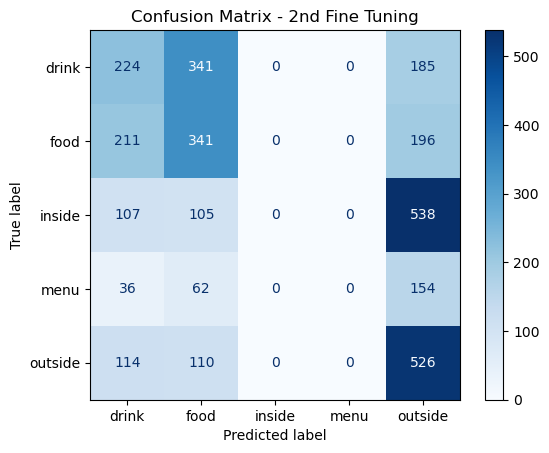

Classification Report (After 2nd Fine Tuning):
              precision    recall  f1-score   support

       drink       0.32      0.30      0.31       750
        food       0.36      0.46      0.40       748
      inside       0.00      0.00      0.00       750
        menu       0.00      0.00      0.00       252
     outside       0.33      0.70      0.45       750

    accuracy                           0.34      3250
   macro avg       0.20      0.29      0.23      3250
weighted avg       0.23      0.34      0.27      3250

Test AUC Score (After 2nd Fine Tuning): 0.6698


C:\Users\gaura\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\gaura\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\gaura\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [27]:
print("Evaluating model after 2nd fine tuning (with augmentation) ...")
results_ft2 = model.evaluate(test_dataset, verbose=0)
print("Test Loss: {:.4f} | Test Accuracy: {:.4f} | Test AUC: {:.4f}".format(*results_ft2))

y_true_all_ft2 = []
y_pred_all_ft2 = []
all_predictions_ft2 = []
for (x_batch, y_batch) in test_dataset:
    preds = model.predict(x_batch)
    all_predictions_ft2.extend(preds)
    y_pred_all_ft2.extend(preds.argmax(axis=1))
    y_true_all_ft2.extend(y_batch.numpy().argmax(axis=1))
all_predictions_ft2 = np.array(all_predictions_ft2)

cm_ft2 = confusion_matrix(y_true_all_ft2, y_pred_all_ft2)
disp_ft2 = ConfusionMatrixDisplay(confusion_matrix=cm_ft2, display_labels=label_vocab)
disp_ft2.plot(cmap='Blues')
plt.title('Confusion Matrix - 2nd Fine Tuning')
plt.show()

print("Classification Report (After 2nd Fine Tuning):")
print(classification_report(y_true_all_ft2, y_pred_all_ft2, target_names=label_vocab))

y_true_onehot_ft2 = tf.keras.utils.to_categorical(y_true_all_ft2, num_classes=len(label_vocab))
overall_auc_ft2 = roc_auc_score(y_true_onehot_ft2, all_predictions_ft2, multi_class='ovr')
print("Test AUC Score (After 2nd Fine Tuning): {:.4f}".format(overall_auc_ft2))


# Step 13: Display Prediction Images vs Actual Images

Below, we randomly select a few test images, display them along with their predicted labels and the actual labels.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step


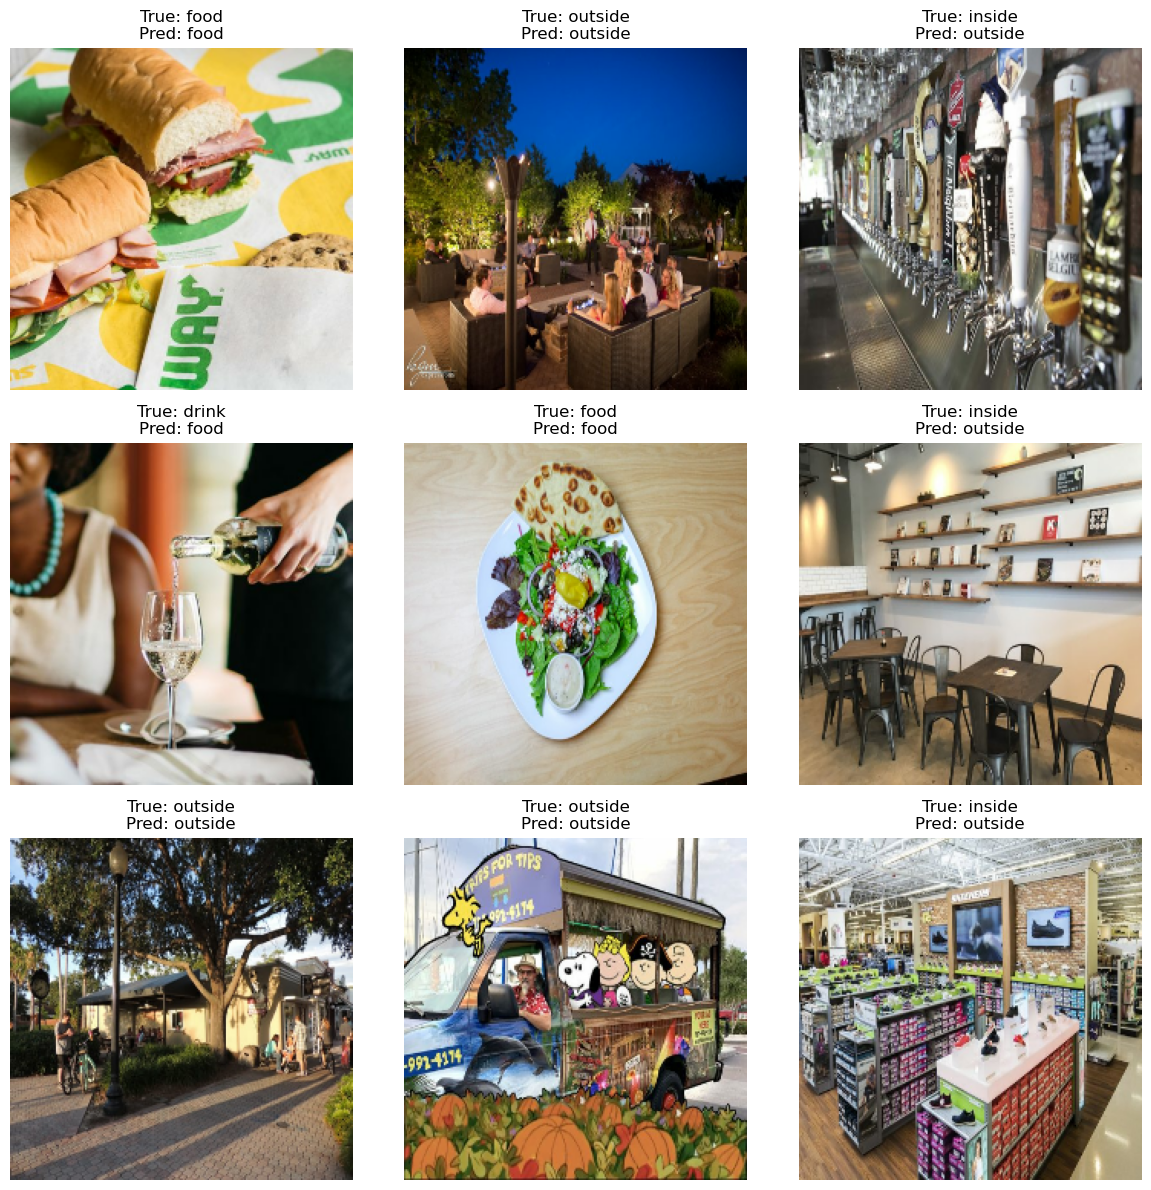

In [52]:
import random
import matplotlib.pyplot as plt
import numpy as np

# Extract one batch from the test dataset
for (images_batch, meta_batch), labels_batch in test_dataset.take(35):
    predictions_batch = model.predict((images_batch, meta_batch))
    break

y_true_batch = labels_batch.numpy().argmax(axis=1)
y_pred_batch = predictions_batch.argmax(axis=1)

num_display = 9
indices = random.sample(range(images_batch.shape[0]), num_display)

plt.figure(figsize=(12, 12))
for i, idx in enumerate(indices):
    img = images_batch[idx].numpy()  
    true_label = label_vocab[y_true_batch[idx]]
    pred_label = label_vocab[y_pred_batch[idx]]
    
    plt.subplot(3, 3, i + 1)
    plt.imshow(np.uint8(img * 255))
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis('off')
plt.tight_layout()
plt.show()
